# NAM Raman Spectrum Processing & DFT Comparison
**Project:** N-Acetylmuramic Acid (NAM) — Raman spectral quality ranking and DFT validation  
**Author:** Sukesh | IIT Jodhpur — Medical Technology  
**Objective:** Load, preprocess, rank experimental Raman spectra → Compare with DFT simulation

---
## Step 1 — Load Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import glob
import re
import os
import warnings
warnings.filterwarnings('ignore')

from scipy.signal import savgol_filter, find_peaks, peak_widths
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# ── Plot style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'legend.fontsize': 10,
    'lines.linewidth': 1.5
})

print('✅ Libraries loaded successfully.')

✅ Libraries loaded successfully.


---
## Configuration — File Paths & Parameters

In [2]:
# ── USER-CONFIGURABLE PATHS ──────────────────────────────────────────────────
# Root folder containing all experimental spectrum files in one place
SPECTRA_ROOT = r"C:\Users\sukes\Downloads\review meeting\NAM-EXP-P\NAM\all_excel_files"

# DFT simulation file
SIM_FILE     = r"C:\Users\sukes\Downloads\review meeting\NAM-EXP-P\NAM\simdata.xlsx"

# Output folder for all saved figures
OUTPUT_DIR   = r"C:\Users\sukes\Downloads\review meeting\NAM-EXP-P\NAM\output_figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── SPECTRAL PARAMETERS ──────────────────────────────────────────────────────
# Experimental/simulated analysis range (cm^-1)
EXP_RANGE   = (200, 3000)

# Savitzky-Golay filter
SG_WINDOW   = 11
SG_POLYORD  = 3

# ALS baseline correction
ALS_LAMBDA  = 1e5
ALS_P       = 0.01
ALS_NITER   = 10

# Reference peak region (cm^-1)
REF_PEAK_CENTER = 1030
REF_PEAK_WIN    = (1000, 1060)

# Noise region (cm^-1) -- assumed peak-free
NOISE_WIN   = (1800, 1900)

# DFT frequency scaling factor
DFT_SCALE   = 0.96

# Gaussian broadening sigma (cm^-1)
GAUSS_SIGMA = 10

# Peak matching tolerance (cm^-1)
MATCH_TOL   = 10

print(f'✅ Configuration set.')
print(f'   Spectra root : {SPECTRA_ROOT}')
print(f'   Simulation   : {SIM_FILE}')
print(f'   Output dir   : {OUTPUT_DIR}')
print(f'   Range        : {EXP_RANGE[0]}-{EXP_RANGE[1]} cm^-1')

✅ Configuration set.
   Spectra root : C:\Users\sukes\Downloads\review meeting\NAM-EXP-P\NAM\all_excel_files
   Simulation   : C:\Users\sukes\Downloads\review meeting\NAM-EXP-P\NAM\simdata.xlsx
   Output dir   : C:\Users\sukes\Downloads\review meeting\NAM-EXP-P\NAM\output_figures
   Range        : 200-3000 cm^-1


---
## Step 2 — Discover & Load All Excel Files

In [3]:
# Recursively find all spectrum xlsx files (excludes simdata.xlsx)
all_files = [
    f for f in glob.glob(os.path.join(SPECTRA_ROOT, '**', '*.xlsx'), recursive=True)
    if 'simdata' not in os.path.basename(f).lower()
]

pattern = re.compile(r'sec-(\d+)_power-(\d+)', re.IGNORECASE)

records = []
for fpath in all_files:
    fname = os.path.basename(fpath)
    m = pattern.search(fname)
    if m:
        records.append({
            'file'  : fpath,
            'fname' : fname,
            'sec'   : int(m.group(1)),
            'power' : int(m.group(2))
        })
    else:
        print(f'⚠️  Could not parse metadata from: {fname}')

df_meta = pd.DataFrame(records)
print(f'\n✅ Found {len(df_meta)} spectrum files.\n')
print(df_meta[['fname','sec','power']].to_string(index=False))


✅ Found 81 spectrum files.

                     fname  sec  power
  sec-10_power-10_i-2.xlsx   10     10
  sec-10_power-15_i-2.xlsx   10     15
  sec-10_power-20_i-2.xlsx   10     20
sec-10_power-20_i-2_2.xlsx   10     20
  sec-10_power-25_i-2.xlsx   10     25
  sec-10_power-30_i-2.xlsx   10     30
  sec-10_power-35_i-2.xlsx   10     35
  sec-10_power-40_i-2.xlsx   10     40
  sec-10_power-45_i-2.xlsx   10     45
  sec-10_power-50_i-2.xlsx   10     50
  sec-10_power-55_i-2.xlsx   10     55
   sec-10_power-5_i-2.xlsx   10      5
  sec-10_power-60_i-2.xlsx   10     60
  sec-10_power-65_i-2.xlsx   10     65
  sec-10_power-70_i-2.xlsx   10     70
  sec-10_power-75_i-2.xlsx   10     75
  sec-10_power-80_i-2.xlsx   10     80
  sec-15_power-10_i-2.xlsx   15     10
  sec-15_power-15_i-2.xlsx   15     15
  sec-15_power-20_i-2.xlsx   15     20
  sec-15_power-25_i-2.xlsx   15     25
  sec-15_power-30_i-2.xlsx   15     30
  sec-15_power-35_i-2.xlsx   15     35
  sec-15_power-40_i-2.xlsx   15    

---
## Step 3–11 — Preprocess All Spectra & Extract Quality Metrics

In [4]:
# ── ALS Baseline Correction ───────────────────────────────────────────────────
def als_baseline(y, lam=1e5, p=0.01, niter=10):
    """Asymmetric Least Squares smoothing for baseline estimation."""
    L = len(y)
    D = diags([1, -2, 1], [0, 1, 2], shape=(L-2, L))
    D = lam * D.T.dot(D)
    w = np.ones(L)
    for _ in range(niter):
        W   = diags(w, 0, shape=(L, L))
        Z   = W + D
        z   = spsolve(Z, w * y)
        w   = np.where(y > z, p, 1 - p)
    return z


def load_shift_intensity(file_path):
    """Load Raman shift/intensity robustly from cleaned or generic Excel layouts."""
    df_raw = pd.read_excel(file_path, header=None)

    # Cleaned files store Raman data in columns C and D.
    # Fallback to A and B for generic two-column files.
    if df_raw.shape[1] >= 4:
        shift_series = pd.to_numeric(df_raw.iloc[:, 2], errors='coerce')
        intensity_series = pd.to_numeric(df_raw.iloc[:, 3], errors='coerce')
    else:
        shift_series = pd.to_numeric(df_raw.iloc[:, 0], errors='coerce')
        intensity_series = pd.to_numeric(df_raw.iloc[:, 1], errors='coerce')

    df_si = pd.DataFrame({'shift': shift_series, 'intensity': intensity_series}).dropna()
    df_si = df_si[(df_si['shift'] >= EXP_RANGE[0]) & (df_si['shift'] <= EXP_RANGE[1])]
    return df_si.reset_index(drop=True)


# ── Main Processing Loop ──────────────────────────────────────────────────────
spectra_data = []   # list of dicts -- one per spectrum

for idx, row in df_meta.iterrows():
    try:
        # --- Read file ---
        df = load_shift_intensity(row['file'])
        if df.empty:
            raise ValueError(
                f'No valid numeric shift/intensity pairs found in range {EXP_RANGE[0]}-{EXP_RANGE[1]} cm^-1.'
            )

        # Step 3 -- clean NaN / non-numeric
        df = df.apply(pd.to_numeric, errors='coerce').dropna()

        # Step 4 -- sort by Raman shift ascending
        df = df.sort_values('shift').reset_index(drop=True)
        shift     = df['shift'].values
        intensity = df['intensity'].values

        # Step 5 -- Savitzky-Golay smoothing (robust window handling)
        min_wl = SG_POLYORD + 2
        if min_wl % 2 == 0:
            min_wl += 1

        max_wl = len(intensity) if len(intensity) % 2 == 1 else len(intensity) - 1
        if max_wl < min_wl:
            raise ValueError(f"Not enough points ({len(intensity)}) for Savitzky-Golay settings (polyorder={SG_POLYORD}).")

        wl = min(SG_WINDOW, max_wl)
        if wl < min_wl:
            wl = min_wl

        smoothed = savgol_filter(intensity, window_length=wl, polyorder=SG_POLYORD)

        # Step 6 -- ALS baseline correction
        baseline  = als_baseline(smoothed, lam=ALS_LAMBDA, p=ALS_P, niter=ALS_NITER)
        corrected = smoothed - baseline
        corrected = np.clip(corrected, 0, None)   # no negative intensities

        # Step 7 -- Normalization
        max_val   = corrected.max()
        normalized = corrected / max_val if max_val > 0 else corrected

        # Step 8 -- Define spectral windows
        ref_mask   = (shift >= REF_PEAK_WIN[0]) & (shift <= REF_PEAK_WIN[1])
        noise_mask = (shift >= NOISE_WIN[0])     & (shift <= NOISE_WIN[1])

        # Step 9 -- Peak detection in reference window
        ref_intensity = corrected[ref_mask]
        ref_shift     = shift[ref_mask]
        peaks_idx, _  = find_peaks(ref_intensity, height=0)

        if len(peaks_idx) == 0:
            # fallback: use the maximum in the window
            peaks_idx = np.array([np.argmax(ref_intensity)])

        best_pk   = peaks_idx[np.argmax(ref_intensity[peaks_idx])]
        peak_pos  = ref_shift[best_pk]
        peak_int  = ref_intensity[best_pk]

        # Step 10 -- SNR
        if noise_mask.sum() > 0:
            noise_std = corrected[noise_mask].std()
        else:
            noise_std = 1e-6
        snr = peak_int / (noise_std + 1e-9)

        # Step 11 -- FWHM / sharpness
        try:
            widths, _, _, _ = peak_widths(ref_intensity, [best_pk], rel_height=0.5)
            # Convert from index units to cm^-1
            d_shift = np.diff(ref_shift).mean() if len(ref_shift) > 1 else 1
            fwhm    = widths[0] * d_shift
        except Exception:
            fwhm = np.nan

        sharpness = 1 / fwhm if (fwhm and fwhm > 0) else 0

        spectra_data.append({
            'file'             : row['file'],
            'fname'            : row['fname'],
            'sec'              : row['sec'],
            'power'            : row['power'],
            'shift'            : shift,
            'intensity'        : intensity,
            'smoothed'         : smoothed,
            'corrected'        : corrected,
            'normalized'       : normalized,
            'peak_pos'         : peak_pos,
            'peak_intensity'   : peak_int,
            'noise_std'        : noise_std,
            'SNR'              : snr,
            'FWHM'             : fwhm,
            'sharpness'        : sharpness,
        })
        print(f'✅ [{idx+1:02d}] {row["fname"]:45s} | SNR={snr:7.1f} | FWHM={fwhm:.2f} cm^-1 | Peak@{peak_pos:.1f}')

    except Exception as e:
        print(f'❌ Error processing {row["fname"]}: {e}')

print(f'\n✅ Processed {len(spectra_data)} spectra in {EXP_RANGE[0]}-{EXP_RANGE[1]} cm^-1 range.')

✅ [01] sec-10_power-10_i-2.xlsx                      | SNR=    5.6 | FWHM=12.77 cm^-1 | Peak@1022.4
✅ [02] sec-10_power-15_i-2.xlsx                      | SNR=   11.1 | FWHM=12.91 cm^-1 | Peak@1024.0


✅ [03] sec-10_power-20_i-2.xlsx                      | SNR=   13.3 | FWHM=11.51 cm^-1 | Peak@1024.0
✅ [04] sec-10_power-20_i-2_2.xlsx                    | SNR=   12.1 | FWHM=13.94 cm^-1 | Peak@1024.0
✅ [05] sec-10_power-25_i-2.xlsx                      | SNR=   19.3 | FWHM=12.50 cm^-1 | Peak@1022.4


✅ [06] sec-10_power-30_i-2.xlsx                      | SNR=   20.8 | FWHM=11.83 cm^-1 | Peak@1024.0
✅ [07] sec-10_power-35_i-2.xlsx                      | SNR=   18.8 | FWHM=13.90 cm^-1 | Peak@1022.4


✅ [08] sec-10_power-40_i-2.xlsx                      | SNR=   20.2 | FWHM=13.21 cm^-1 | Peak@1024.0
✅ [09] sec-10_power-45_i-2.xlsx                      | SNR=   24.7 | FWHM=11.22 cm^-1 | Peak@1024.0


✅ [10] sec-10_power-50_i-2.xlsx                      | SNR=   24.2 | FWHM=13.53 cm^-1 | Peak@1024.0
✅ [11] sec-10_power-55_i-2.xlsx                      | SNR=   26.7 | FWHM=12.35 cm^-1 | Peak@1024.0


...

✅ [70] sec-5_power-30_i-2.xlsx                       | SNR=    9.4 | FWHM=11.31 cm^-1 | Peak@1024.0
✅ [71] sec-5_power-35_i-2.xlsx                       | SNR=    8.7 | FWHM=10.39 cm^-1 | Peak@1022.4


✅ [72] sec-5_power-40_i-2.xlsx                       | SNR=    9.9 | FWHM=11.78 cm^-1 | Peak@1022.4
✅ [73] sec-5_power-45_i-2.xlsx                       | SNR=   10.9 | FWHM=11.41 cm^-1 | Peak@1024.0


✅ [74] sec-5_power-50_i-2.xlsx                       | SNR=   12.0 | FWHM=10.98 cm^-1 | Peak@1024.0
✅ [75] sec-5_power-55_i-2.xlsx                       | SNR=   13.3 | FWHM=11.44 cm^-1 | Peak@1022.4


✅ [76] sec-5_power-5_i-2.xlsx                        | SNR=    6.0 | FWHM=14.66 cm^-1 | Peak@1024.0
✅ [77] sec-5_power-60_i-2.xlsx                       | SNR=   14.9 | FWHM=10.31 cm^-1 | Peak@1024.0
✅ [78] sec-5_power-65_i-2.xlsx                       | SNR=   12.5 | FWHM=11.49 cm^-1 | Peak@1024.0


✅ [79] sec-5_power-70_i-2.xlsx                       | SNR=   14.5 | FWHM=12.66 cm^-1 | Peak@1024.0
✅ [80] sec-5_power-75_i-2.xlsx                       | SNR=   16.2 | FWHM=11.33 cm^-1 | Peak@1024.0
✅ [81] sec-5_power-80_i-2.xlsx                       | SNR=   15.5 | FWHM=10.90 cm^-1 | Peak@1022.4

✅ Processed 81 spectra in 200-3000 cm^-1 range.


---
## Step 12 & 13 — Compute Score & Rank Spectra

In [5]:
results = []
for s in spectra_data:
    score = (0.5 * s['SNR']
           + 0.3 * s['peak_intensity']
           + 0.2 * s['sharpness'])
    results.append({
        'fname'          : s['fname'],
        'sec'            : s['sec'],
        'power'          : s['power'],
        'SNR'            : round(s['SNR'], 2),
        'peak_intensity' : round(s['peak_intensity'], 2),
        'FWHM'           : round(s['FWHM'], 3) if not np.isnan(s['FWHM']) else np.nan,
        'sharpness'      : round(s['sharpness'], 4),
        'score'          : round(score, 4)
    })

if not results:
    raise ValueError(
        'No spectra were scored. Check preprocessing output in Cell 9 and ensure valid Raman columns were loaded.'
    )

df_results = pd.DataFrame(results).sort_values('score', ascending=False).reset_index(drop=True)
df_results.index += 1
df_results.index.name = 'rank'

print('\n📊 RANKED SPECTRA TABLE')
print('=' * 90)
print(df_results.to_string())
print('=' * 90)


📊 RANKED SPECTRA TABLE
                           fname  sec  power    SNR  peak_intensity    FWHM  sharpness     score
rank                                                                                            
1       sec-25_power-80_i-2.xlsx   25     80  95.91          583.47  12.216     0.0819  223.0141
2       sec-25_power-75_i-2.xlsx   25     75  52.13          568.99  12.588     0.0794  196.7804
3       sec-25_power-70_i-2.xlsx   25     70  65.44          514.79  12.682     0.0789  187.1737
4       sec-25_power-65_i-2.xlsx   25     65  63.29          476.88  12.707     0.0787  174.7219
5       sec-20_power-80_i-2.xlsx   20     80  56.46          483.83  12.051     0.0830  173.3964
6       sec-25_power-60_i-2.xlsx   25     60  53.04          461.03  12.566     0.0796  164.8453
7       sec-20_power-75_i-2.xlsx   20     75  47.31          469.83  12.315     0.0812  164.6190
8       sec-25_power-55_i-2.xlsx   25     55  62.15          432.01  12.711     0.0787  160.6919
9     

---
## Step 14 — Identify Best Acquisition Conditions

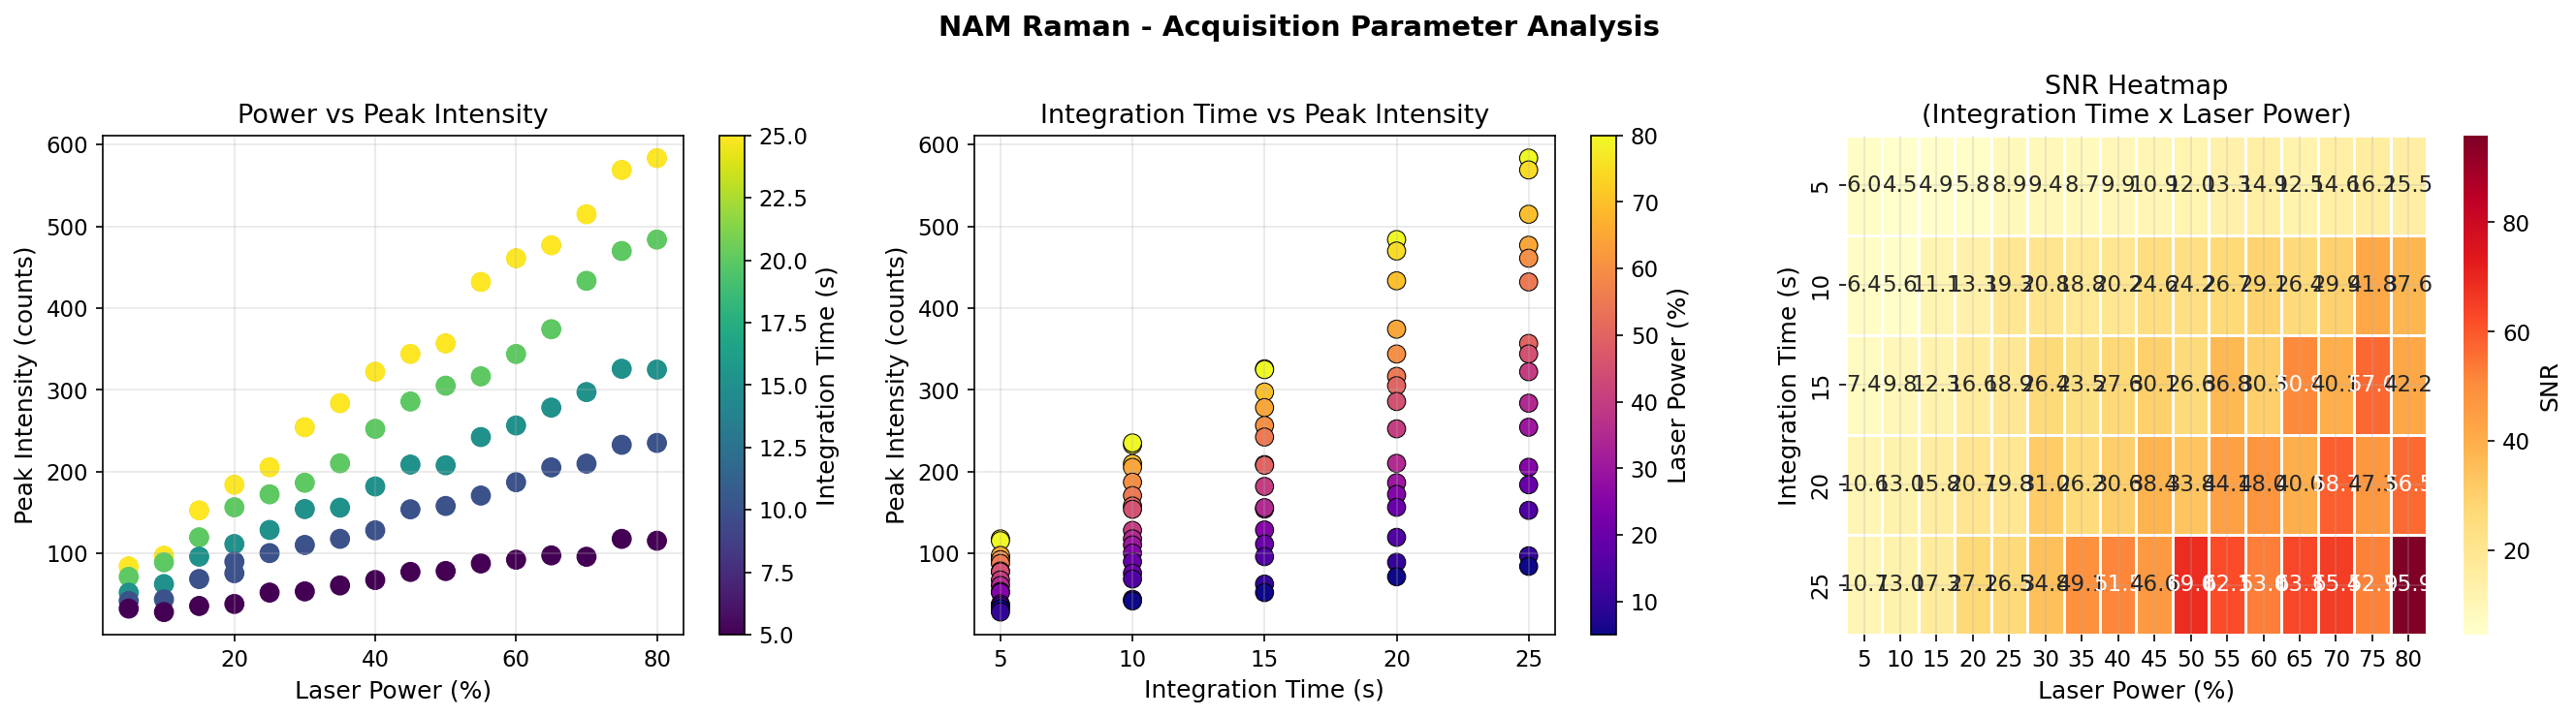

💾 Saved -> C:\Users\sukes\Downloads\review meeting\NAM-EXP-P\NAM\output_figures\fig01_acquisition_parameter_analysis.png

Text Summary (Figure 1)
  Best composite score : sec=25 s, power=80 %, score=223.014
  Highest SNR          : sec=25 s, power=80 %, SNR=95.91
  Total spectra used   : 81


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('NAM Raman - Acquisition Parameter Analysis', fontsize=14, fontweight='bold')

# -- Plot 1: Power vs Peak Intensity -----------------------------------------
ax = axes[0]
ax.scatter(df_results['power'], df_results['peak_intensity'],
           c=df_results['sec'], cmap='viridis', s=80, edgecolors='k', linewidths=0.5)
sc = ax.scatter(df_results['power'], df_results['peak_intensity'],
                c=df_results['sec'], cmap='viridis', s=80)
plt.colorbar(sc, ax=ax, label='Integration Time (s)')
ax.set_xlabel('Laser Power (%)')
ax.set_ylabel('Peak Intensity (counts)')
ax.set_title('Power vs Peak Intensity')

# -- Plot 2: Integration Time vs Peak Intensity -------------------------------
ax = axes[1]
sc2 = ax.scatter(df_results['sec'], df_results['peak_intensity'],
                 c=df_results['power'], cmap='plasma', s=80, edgecolors='k', linewidths=0.5)
plt.colorbar(sc2, ax=ax, label='Laser Power (%)')
ax.set_xlabel('Integration Time (s)')
ax.set_ylabel('Peak Intensity (counts)')
ax.set_title('Integration Time vs Peak Intensity')

# -- Plot 3: SNR Heatmap -------------------------------------------------------
ax = axes[2]
pivot_snr = df_results.pivot_table(values='SNR', index='sec', columns='power', aggfunc='max')
sns.heatmap(pivot_snr, ax=ax, cmap='YlOrRd', annot=True, fmt='.1f',
            linewidths=0.5, cbar_kws={'label': 'SNR'})
ax.set_xlabel('Laser Power (%)')
ax.set_ylabel('Integration Time (s)')
ax.set_title('SNR Heatmap\n(Integration Time x Laser Power)')

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'fig01_acquisition_parameter_analysis.png')
plt.savefig(save_path, bbox_inches='tight')
plt.show()
print(f'💾 Saved -> {save_path}')

# Text summary under output
best_by_score = df_results.iloc[0]
best_by_snr = df_results.loc[df_results['SNR'].idxmax()]
print('\nText Summary (Figure 1)')
print(f"  Best composite score : sec={int(best_by_score['sec'])} s, power={int(best_by_score['power'])} %, score={best_by_score['score']:.3f}")
print(f"  Highest SNR          : sec={int(best_by_snr['sec'])} s, power={int(best_by_snr['power'])} %, SNR={best_by_snr['SNR']:.2f}")
print(f"  Total spectra used   : {len(df_results)}")

---
## Step 15 — Select Top 2 Best Spectra

In [7]:
top2_fnames = df_results['fname'].head(2).tolist()
top2_data   = [s for s in spectra_data if s['fname'] in top2_fnames]

print('🏆 Top 2 Best Spectra Selected:')
for i, s in enumerate(top2_data, 1):
    print(f'  #{i}: {s["fname"]}  |  sec={s["sec"]}s  |  power={s["power"]}%  |  SNR={s["SNR"]:.1f}')

🏆 Top 2 Best Spectra Selected:
  #1: sec-25_power-75_i-2.xlsx  |  sec=25s  |  power=75%  |  SNR=52.1
  #2: sec-25_power-80_i-2.xlsx  |  sec=25s  |  power=80%  |  SNR=95.9


---
## Step 16 — Plot Best Spectra with Full Peak Detection

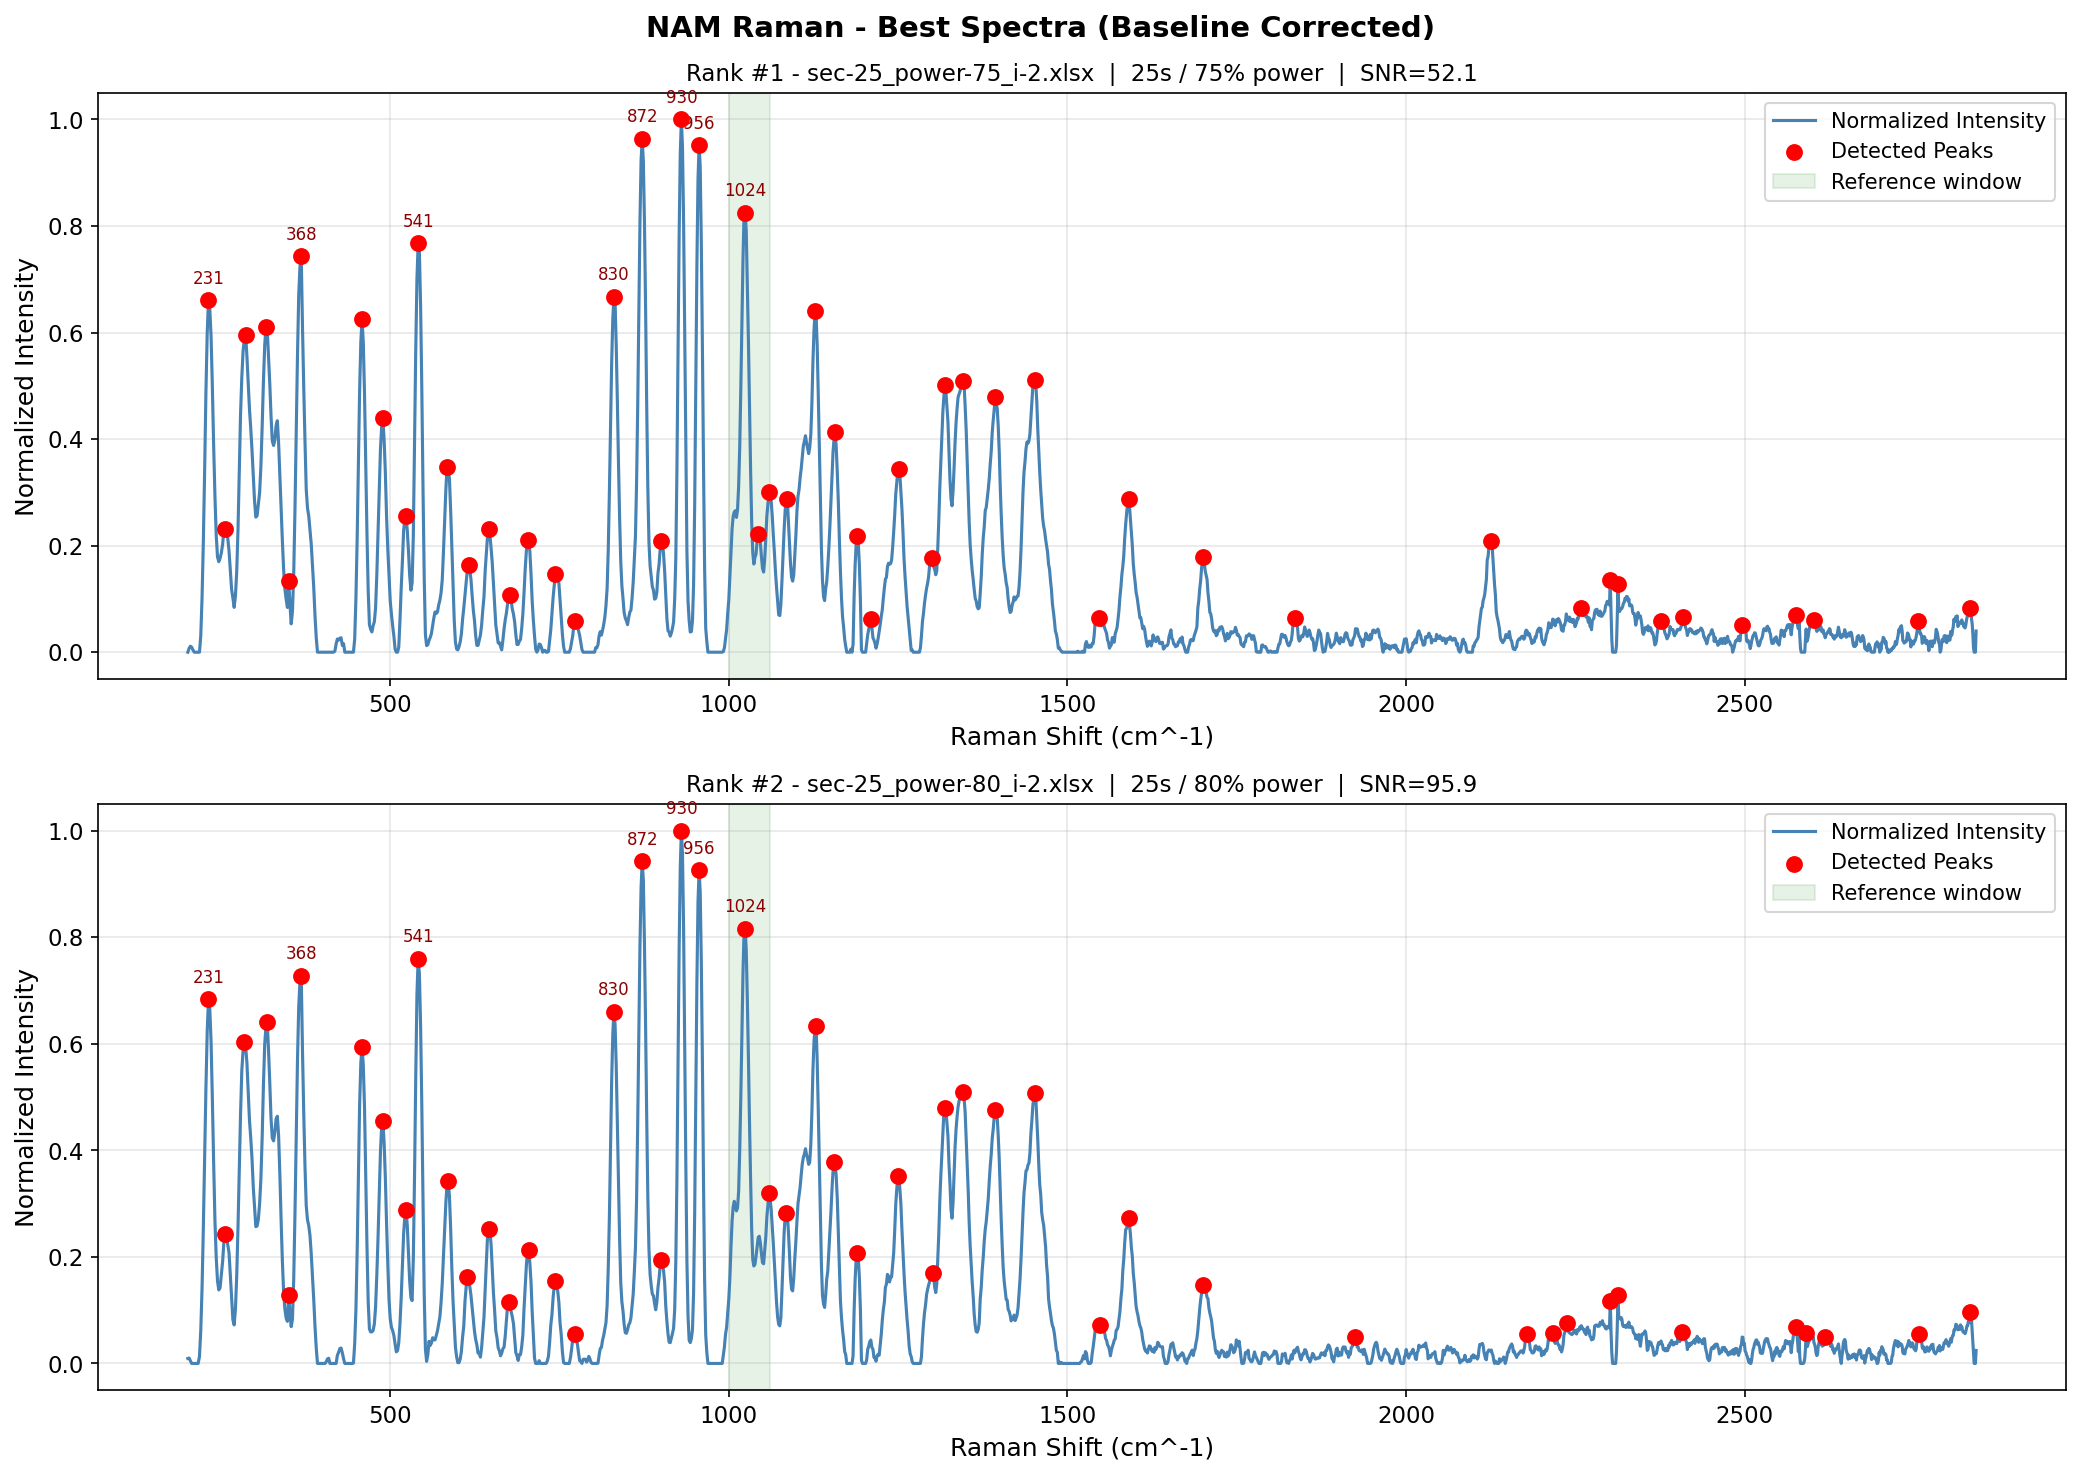

💾 Saved -> C:\Users\sukes\Downloads\review meeting\NAM-EXP-P\NAM\output_figures\fig02_best_spectra_annotated.png

Text Summary (Figure 2)
  sec-25_power-75_i-2.xlsx: detected_peaks=51, strongest_peaks(cm^-1)=930, 872, 956
  sec-25_power-80_i-2.xlsx: detected_peaks=49, strongest_peaks(cm^-1)=930, 872, 956


In [8]:
fig, axes = plt.subplots(len(top2_data), 1, figsize=(14, 5 * len(top2_data)))
if len(top2_data) == 1:
    axes = [axes]

fig.suptitle('NAM Raman - Best Spectra (Baseline Corrected)', fontsize=14, fontweight='bold')

peak_report = []

for i, (s, ax) in enumerate(zip(top2_data, axes)):
    shift      = s['shift']
    normalized = s['normalized']

    # Detect peaks across full spectrum
    peaks, props = find_peaks(normalized, height=0.05, prominence=0.03, distance=10)

    ax.plot(shift, normalized, color='steelblue', linewidth=1.5, label='Normalized Intensity')
    ax.scatter(shift[peaks], normalized[peaks], color='red', s=50, zorder=5, label='Detected Peaks')

    # Annotate top 8 peaks by intensity
    top_peaks = sorted(peaks, key=lambda p: normalized[p], reverse=True)[:8]
    for pk in top_peaks:
        ax.annotate(f'{shift[pk]:.0f}',
                    xy=(shift[pk], normalized[pk]),
                    xytext=(0, 8), textcoords='offset points',
                    fontsize=8, ha='center', color='darkred')

    # Save short text summary data
    strongest_peaks = [float(shift[p]) for p in top_peaks[:3]]
    peak_report.append({
        'fname': s['fname'],
        'n_peaks': int(len(peaks)),
        'strongest_peaks': strongest_peaks
    })

    # Shade reference region
    ax.axvspan(*REF_PEAK_WIN, alpha=0.1, color='green', label='Reference window')

    ax.set_title(f'Rank #{i+1} - {s["fname"]}  |  {s["sec"]}s / {s["power"]}% power  |  SNR={s["SNR"]:.1f}', fontsize=11)
    ax.set_xlabel('Raman Shift (cm^-1)')
    ax.set_ylabel('Normalized Intensity')
    ax.legend(loc='upper right')

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'fig02_best_spectra_annotated.png')
plt.savefig(save_path, bbox_inches='tight')
plt.show()
print(f'💾 Saved -> {save_path}')

# Text summary under output
print('\nText Summary (Figure 2)')
for r in peak_report:
    peak_text = ', '.join([f'{p:.0f}' for p in r['strongest_peaks']])
    print(f"  {r['fname']}: detected_peaks={r['n_peaks']}, strongest_peaks(cm^-1)={peak_text}")

---
## Step 17 — Export Processed Spectra as CSV

In [9]:
exported_csvs = []

for s in top2_data:
    base    = os.path.splitext(s['fname'])[0]
    csvname = f'processed_{base}.csv'
    csvpath = os.path.join(OUTPUT_DIR, csvname)

    df_export = pd.DataFrame({
        'raman_shift (cm-1)'  : s['shift'],
        'normalized_intensity': s['normalized']
    })
    df_export.to_csv(csvpath, index=False)
    exported_csvs.append(csvpath)
    print(f'💾 Exported CSV → {csvpath}')

# Also export ranked table
ranked_csv = os.path.join(OUTPUT_DIR, 'ranked_spectra_table.csv')
df_results.to_csv(ranked_csv)
print(f'💾 Exported ranked table → {ranked_csv}')

💾 Exported CSV → C:\Users\sukes\Downloads\review meeting\NAM-EXP-P\NAM\output_figures\processed_sec-25_power-75_i-2.csv
💾 Exported CSV → C:\Users\sukes\Downloads\review meeting\NAM-EXP-P\NAM\output_figures\processed_sec-25_power-80_i-2.csv
💾 Exported ranked table → C:\Users\sukes\Downloads\review meeting\NAM-EXP-P\NAM\output_figures\ranked_spectra_table.csv


---
## Step 18 — Load & Prepare DFT Simulation Data

In [10]:
# ── Load DFT simulation file ─────────────────────────────────────────────────
# Expected columns: frequency (cm⁻¹), raman_activity
# Adapt column indices below if your simdata.xlsx uses different headers.
df_sim = pd.read_excel(SIM_FILE)
print('DFT file columns:', df_sim.columns.tolist())
print(df_sim.head())

DFT file columns: ['X', 'Y']
    X         Y
0   0  0.002597
1   8  0.004403
2  16  0.009520
3  24  0.036769
4  32  0.070849


In [11]:
# -- ADAPT THESE COLUMN NAMES to match your simdata.xlsx ----------------------
# Common DFT output column names -- change if needed:
FREQ_COL     = df_sim.columns[0]   # first  column -> frequency
ACTIVITY_COL = df_sim.columns[1]   # second column -> Raman activity

df_sim = df_sim[[FREQ_COL, ACTIVITY_COL]].copy()
df_sim.columns = ['frequency', 'activity']
df_sim = df_sim.dropna()
df_sim = df_sim[df_sim['frequency'] > 0]   # remove imaginary/zero modes

# Step 18a -- Apply DFT frequency scaling
df_sim['scaled_freq'] = df_sim['frequency'] * DFT_SCALE

# Step 18b -- Keep only selected spectral range
df_sim = df_sim[
    (df_sim['scaled_freq'] >= EXP_RANGE[0]) &
    (df_sim['scaled_freq'] <= EXP_RANGE[1])
].copy()

if df_sim.empty:
    raise ValueError(f'No simulated modes found in selected range {EXP_RANGE[0]}-{EXP_RANGE[1]} cm^-1.')

# Step 18c -- Normalize activity within selected range
df_sim['norm_activity'] = df_sim['activity'] / df_sim['activity'].max()

print(f'\n✅ Loaded {len(df_sim)} DFT vibrational modes in selected range.')
print(f'   Selected range : {EXP_RANGE[0]} - {EXP_RANGE[1]} cm^-1')
print(f'   Frequency span : {df_sim["scaled_freq"].min():.1f} - {df_sim["scaled_freq"].max():.1f} cm^-1')
print(df_sim[['scaled_freq','activity','norm_activity']].head(10).to_string(index=False))


✅ Loaded 364 DFT vibrational modes in selected range.
   Selected range : 200 - 3000 cm^-1
   Frequency span : 207.4 - 2995.2 cm^-1
 scaled_freq  activity  norm_activity
      207.36  0.082627       0.007037
      215.04  0.079292       0.006753
      222.72  0.081922       0.006977
      230.40  0.036246       0.003087
      238.08  0.020732       0.001766
      245.76  0.024797       0.002112
      253.44  0.091366       0.007781
      261.12  0.050850       0.004330
      268.80  0.079324       0.006755
      276.48  0.230529       0.019632


In [12]:
# Step 18c — Gaussian broadening of DFT stick spectrum
# Use same x-axis as best experimental spectrum
best_spectrum = top2_data[0]
x_exp = best_spectrum['shift']

def gaussian_broadening(x_grid, stick_freqs, stick_intensities, sigma=10):
    """Convert discrete DFT stick spectrum to continuous Gaussian-broadened spectrum."""
    y = np.zeros_like(x_grid, dtype=float)
    for freq, intensity in zip(stick_freqs, stick_intensities):
        y += intensity * np.exp(-0.5 * ((x_grid - freq) / sigma) ** 2)
    return y

y_sim_broad = gaussian_broadening(
    x_exp,
    df_sim['scaled_freq'].values,
    df_sim['norm_activity'].values,
    sigma=GAUSS_SIGMA
)

# Normalize broadened spectrum
if y_sim_broad.max() > 0:
    y_sim_broad /= y_sim_broad.max()

print('✅ Gaussian broadening applied (σ = 10 cm⁻¹).')

✅ Gaussian broadening applied (σ = 10 cm⁻¹).


---
## Step 19 — Experimental vs Simulated Spectrum Overlay

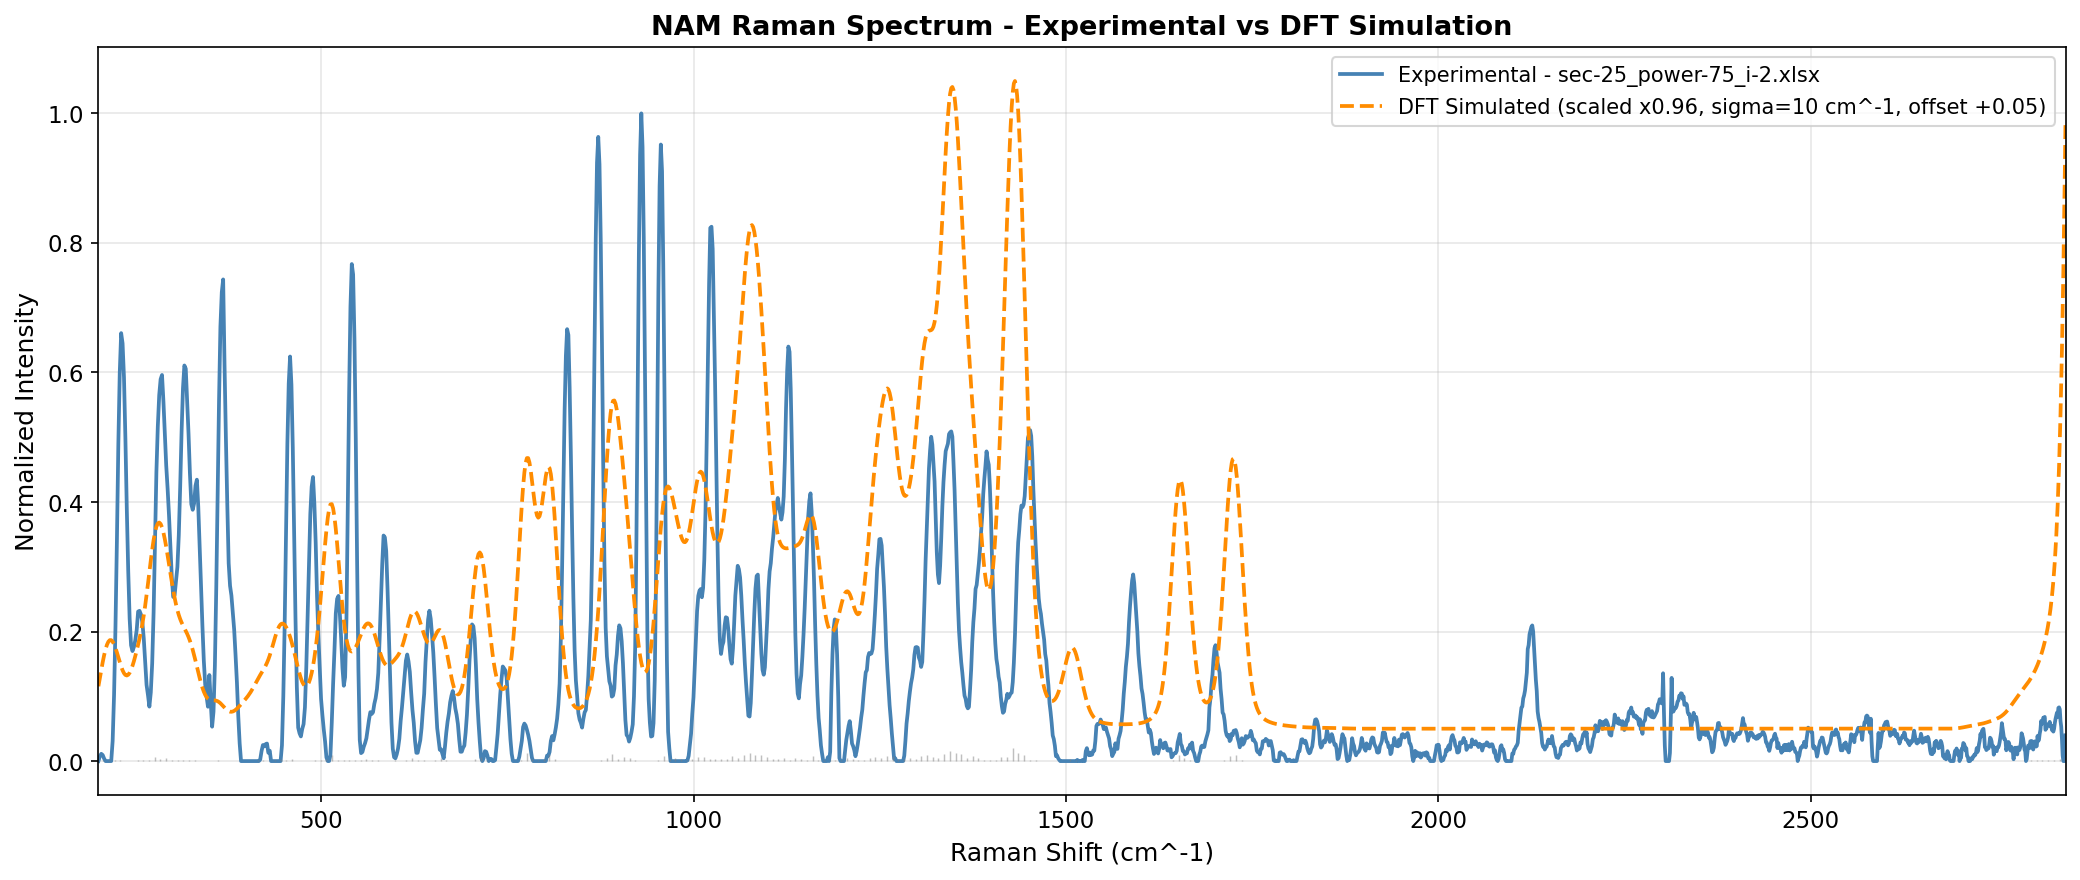

💾 Saved -> C:\Users\sukes\Downloads\review meeting\NAM-EXP-P\NAM\output_figures\fig03_experimental_vs_DFT_overlay.png

Text Summary (Figure 3)
  Experimental file      : sec-25_power-75_i-2.xlsx
  Comparison range       : 200.8 to 2841.9 cm^-1
  Simulated modes used   : 364
  Overlay correlation    : 0.382


In [13]:
fig, ax = plt.subplots(figsize=(14, 6))

# Experimental
ax.plot(x_exp, best_spectrum['normalized'],
        color='steelblue', linewidth=1.8,
        label=f'Experimental - {best_spectrum["fname"]}')

# Simulated (offset upward for clarity)
offset = 0.05
ax.plot(x_exp, y_sim_broad + offset,
        color='darkorange', linewidth=1.8, linestyle='--',
        label=f'DFT Simulated (scaled x{DFT_SCALE}, sigma={GAUSS_SIGMA} cm^-1, offset +{offset})')

# DFT stick spectrum
for _, drow in df_sim.iterrows():
    if x_exp.min() <= drow['scaled_freq'] <= x_exp.max():
        ax.vlines(drow['scaled_freq'], 0, drow['norm_activity'] * 0.3,
                  color='gray', linewidth=0.7, alpha=0.5)

ax.set_xlabel('Raman Shift (cm^-1)', fontsize=12)
ax.set_ylabel('Normalized Intensity', fontsize=12)
ax.set_title('NAM Raman Spectrum - Experimental vs DFT Simulation', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(x_exp.min(), x_exp.max())

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'fig03_experimental_vs_DFT_overlay.png')
plt.savefig(save_path, bbox_inches='tight')
plt.show()
print(f'💾 Saved -> {save_path}')

# Text summary under output
if len(best_spectrum['normalized']) == len(y_sim_broad):
    overlay_corr = float(np.corrcoef(best_spectrum['normalized'], y_sim_broad)[0, 1])
else:
    overlay_corr = np.nan

print('\nText Summary (Figure 3)')
print(f"  Experimental file      : {best_spectrum['fname']}")
print(f"  Comparison range       : {x_exp.min():.1f} to {x_exp.max():.1f} cm^-1")
print(f"  Simulated modes used   : {len(df_sim)}")
print(f"  Overlay correlation    : {overlay_corr:.3f}")

---
## Step 20 — Automatic Peak Matching (±10 cm⁻¹ tolerance)

In [14]:
# Detect experimental peaks
exp_peaks_idx, _ = find_peaks(best_spectrum['normalized'], height=0.05, prominence=0.03, distance=10)
exp_peak_positions = best_spectrum['shift'][exp_peaks_idx]

# DFT peak positions (scaled)
dft_peak_positions = df_sim['scaled_freq'].values

# Match each experimental peak to nearest DFT peak within tolerance
matches = []
for ep in exp_peak_positions:
    diffs = np.abs(dft_peak_positions - ep)
    min_idx = np.argmin(diffs)
    if diffs[min_idx] <= MATCH_TOL:
        matches.append({
            'Experimental (cm⁻¹)' : round(ep, 1),
            'DFT Simulated (cm⁻¹)': round(dft_peak_positions[min_idx], 1),
            'Difference (cm⁻¹)'   : round(ep - dft_peak_positions[min_idx], 1),
            'DFT Raman Activity'   : round(df_sim.iloc[min_idx]['activity'], 3)
        })

df_matches = pd.DataFrame(matches).sort_values('Experimental (cm⁻¹)').reset_index(drop=True)
df_matches.index += 1

print(f'\n📋 PEAK MATCHING TABLE (tolerance = ±{MATCH_TOL} cm⁻¹)')
print('=' * 65)
print(df_matches.to_string())
print('=' * 65)
print(f'\n✅ {len(df_matches)} matched peaks out of {len(exp_peak_positions)} experimental peaks detected.')

# Save table
match_csv = os.path.join(OUTPUT_DIR, 'peak_matching_table.csv')
df_matches.to_csv(match_csv)
print(f'💾 Saved → {match_csv}')


📋 PEAK MATCHING TABLE (tolerance = ±10 cm⁻¹)
    Experimental (cm⁻¹)  DFT Simulated (cm⁻¹)  Difference (cm⁻¹)  DFT Raman Activity
1                 231.4                 230.4                1.0               0.036
2                 256.0                 253.4                2.6               0.091
3                 286.2                 284.2                2.1               0.144
4                 316.2                 314.9                1.4               0.079
5                 349.8                 353.3               -3.5               0.017
6                 368.3                 368.6               -0.3               0.010
7                 458.2                 460.8               -2.6               0.104
8                 489.0                 491.5               -2.6               0.046
9                 523.1                 522.2                0.9               0.070
10                541.0                 537.6                3.4               0.049
11                5

---
## Step 21 — Supplementary Plots

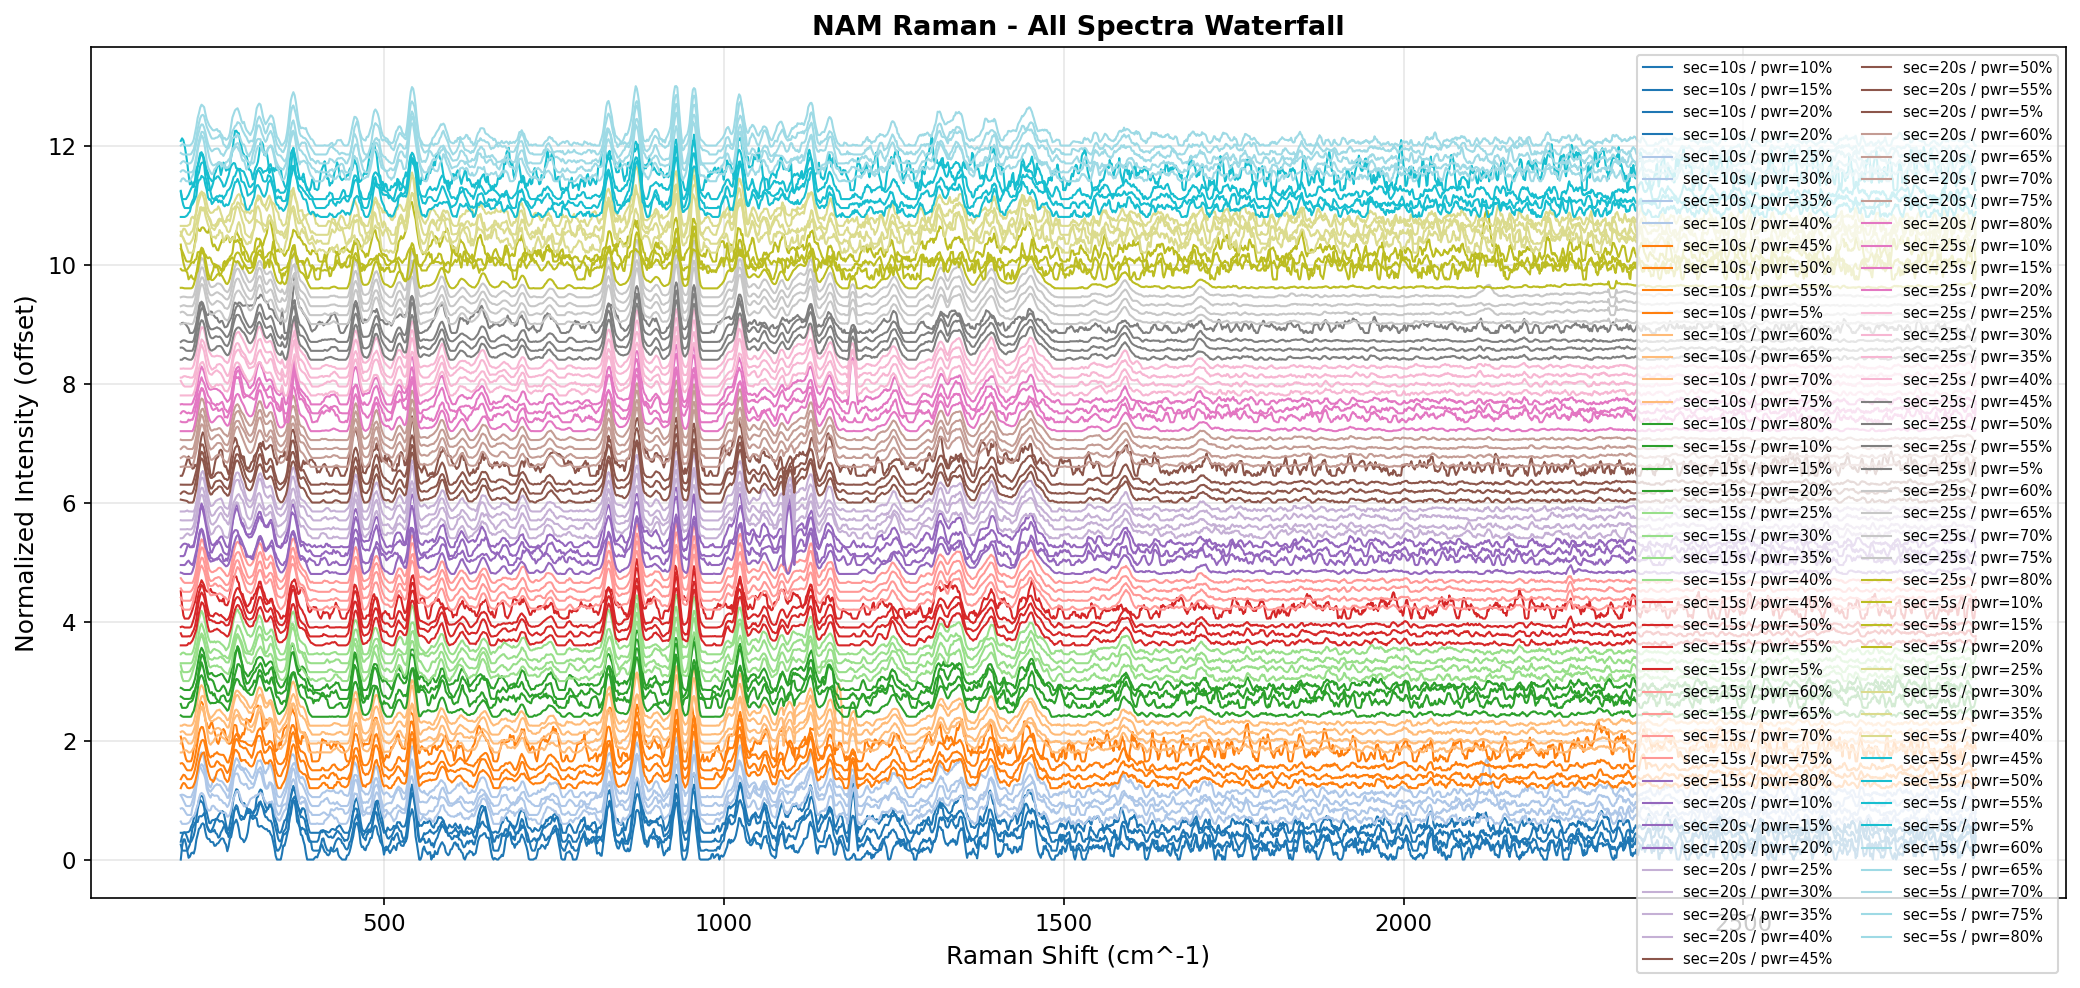

💾 Saved -> C:\Users\sukes\Downloads\review meeting\NAM-EXP-P\NAM\output_figures\fig04_all_spectra_waterfall.png

Text Summary (Figure 4)
  Spectra plotted : 81
  Raman range     : 200-3000 cm^-1
  Vertical offset : 0.15 per spectrum


In [15]:
# -- Fig 4: All Spectra Overlay (waterfall) -----------------------------------
fig, ax = plt.subplots(figsize=(14, 7))
colors = cm.tab20(np.linspace(0, 1, len(spectra_data)))

for i, s in enumerate(spectra_data):
    label = f"sec={s['sec']}s / pwr={s['power']}%"
    offset = i * 0.15
    ax.plot(s['shift'], s['normalized'] + offset, color=colors[i], linewidth=1, label=label)

ax.set_xlabel('Raman Shift (cm^-1)')
ax.set_ylabel('Normalized Intensity (offset)')
ax.set_title('NAM Raman - All Spectra Waterfall', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=7, ncol=2)
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'fig04_all_spectra_waterfall.png')
plt.savefig(save_path, bbox_inches='tight')
plt.show()
print(f'💾 Saved -> {save_path}')

# Text summary under output
print('\nText Summary (Figure 4)')
print(f'  Spectra plotted : {len(spectra_data)}')
print(f'  Raman range     : {EXP_RANGE[0]}-{EXP_RANGE[1]} cm^-1')
print('  Vertical offset : 0.15 per spectrum')

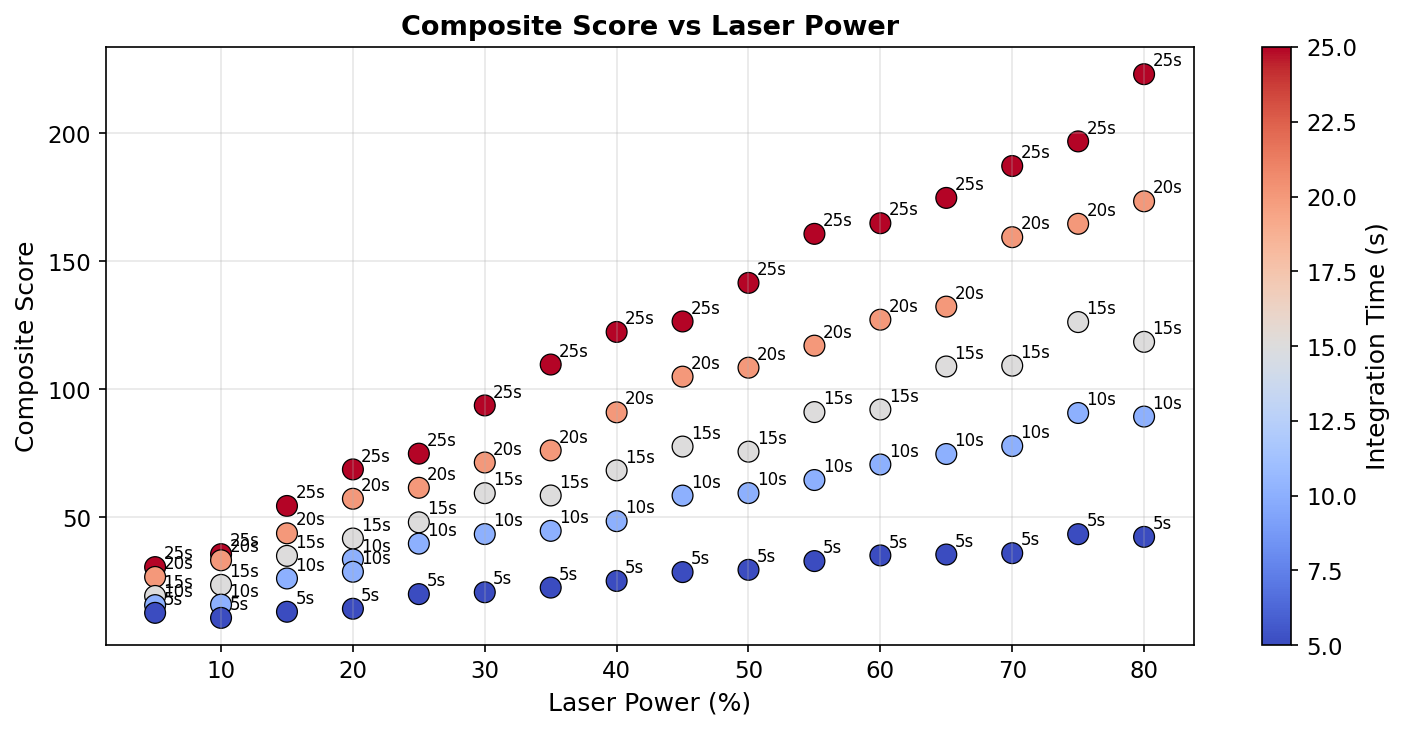

💾 Saved -> C:\Users\sukes\Downloads\review meeting\NAM-EXP-P\NAM\output_figures\fig05_score_vs_power.png

Text Summary (Figure 5)
  Power 80% -> mean composite score 129.349
  Power 75% -> mean composite score 124.381
  Power 70% -> mean composite score 113.948


In [16]:
# -- Fig 5: Score vs Power colored by Integration Time ------------------------
fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(df_results['power'], df_results['score'],
                c=df_results['sec'], cmap='coolwarm', s=100, edgecolors='k', linewidths=0.6)
plt.colorbar(sc, ax=ax, label='Integration Time (s)')

# Annotate each point
for _, row in df_results.iterrows():
    ax.annotate(f"{row['sec']}s",
                (row['power'], row['score']),
                xytext=(4, 4), textcoords='offset points', fontsize=8)

ax.set_xlabel('Laser Power (%)')
ax.set_ylabel('Composite Score')
ax.set_title('Composite Score vs Laser Power', fontsize=13, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'fig05_score_vs_power.png')
plt.savefig(save_path, bbox_inches='tight')
plt.show()
print(f'💾 Saved -> {save_path}')

# Text summary under output
power_summary = df_results.groupby('power')['score'].mean().sort_values(ascending=False).head(3)
print('\nText Summary (Figure 5)')
for p, v in power_summary.items():
    print(f'  Power {int(p)}% -> mean composite score {v:.3f}')

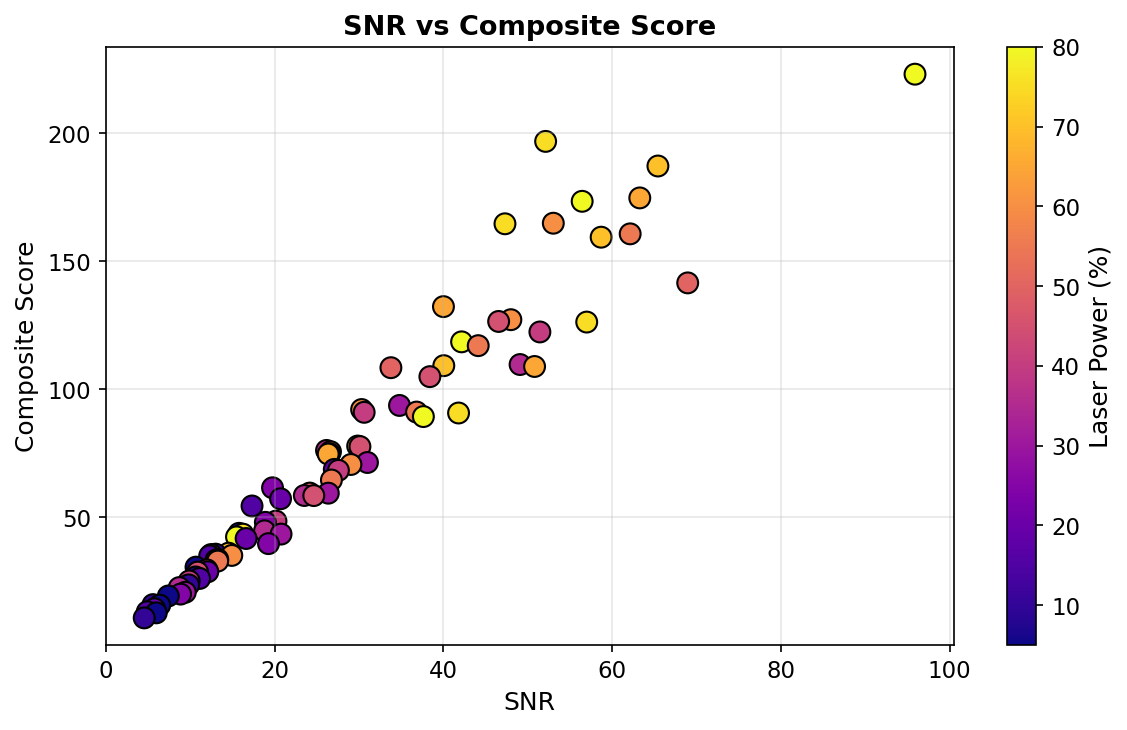

💾 Saved -> C:\Users\sukes\Downloads\review meeting\NAM-EXP-P\NAM\output_figures\fig06_SNR_vs_score.png

Text Summary (Figure 6)
  Correlation(SNR, score): 0.965
  Score range            : 10.793 to 223.014


In [17]:
# -- Fig 6: SNR vs Score scatter -----------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(df_results['SNR'], df_results['score'],
                c=df_results['power'], cmap='plasma', s=100, edgecolors='k')
plt.colorbar(sc, ax=ax, label='Laser Power (%)')
ax.set_xlabel('SNR')
ax.set_ylabel('Composite Score')
ax.set_title('SNR vs Composite Score', fontsize=13, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'fig06_SNR_vs_score.png')
plt.savefig(save_path, bbox_inches='tight')
plt.show()
print(f'💾 Saved -> {save_path}')

# Text summary under output
snr_score_corr = float(np.corrcoef(df_results['SNR'], df_results['score'])[0, 1]) if len(df_results) > 1 else np.nan
print('\nText Summary (Figure 6)')
print(f'  Correlation(SNR, score): {snr_score_corr:.3f}')
print(f"  Score range            : {df_results['score'].min():.3f} to {df_results['score'].max():.3f}")

---
## Final Summary

In [18]:
from datetime import datetime

best = df_results.iloc[0]

print('=' * 60)
print('  NAM RAMAN ANALYSIS - FINAL SUMMARY')
print('=' * 60)
print(f'  Total spectra processed   : {len(spectra_data)}')
print(f'\n  Best Acquisition Conditions:')
print(f'     Integration time : {best["sec"]} seconds')
print(f'     Laser power      : {best["power"]} %')
print(f'     SNR              : {best["SNR"]}')
print(f'     Composite score  : {best["score"]}')
print(f'\n  Peak Matching:')
print(f'     Matched peaks    : {len(df_matches)}')
print(f'\n  Outputs saved to:')
print(f'     {OUTPUT_DIR}')
print()

saved_files = [
    'fig01_acquisition_parameter_analysis.png',
    'fig02_best_spectra_annotated.png',
    'fig03_experimental_vs_DFT_overlay.png',
    'fig04_all_spectra_waterfall.png',
    'fig05_score_vs_power.png',
    'fig06_SNR_vs_score.png',
    'ranked_spectra_table.csv',
    'peak_matching_table.csv',
]

for f in saved_files:
    print(f'     ✅ {f}')

# Build a detailed text report file
report_path = os.path.join(OUTPUT_DIR, 'NAM_analysis_report.txt')

input_file_sample = df_meta['fname'].head(5).tolist()
exp_sample = pd.DataFrame({
    'raman_shift_cm^-1': best_spectrum['shift'][:5],
    'normalized_intensity': best_spectrum['normalized'][:5]
})
sim_sample = df_sim[['scaled_freq', 'norm_activity']].head(5).copy()

report_lines = []
report_lines.append('NAM RAMAN ANALYSIS REPORT')
report_lines.append('=' * 80)
report_lines.append(f'Generated on: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
report_lines.append('')
report_lines.append('TITLE')
report_lines.append('Raman Spectral Quality Ranking and DFT Validation for NAM')
report_lines.append('')
report_lines.append('INPUT')
report_lines.append(f'- Spectra root: {SPECTRA_ROOT}')
report_lines.append(f'- Simulation file: {SIM_FILE}')
report_lines.append(f'- Number of spectra loaded: {len(df_meta)}')
report_lines.append(f'- Analysis range: {EXP_RANGE[0]}-{EXP_RANGE[1]} cm^-1')
report_lines.append('- Input sample files:')
for f in input_file_sample:
    report_lines.append(f'  * {f}')
report_lines.append('')
report_lines.append('PROCESSING PIPELINE')
report_lines.append('1. Load all spectrum Excel files.')
report_lines.append('2. Extract Raman shift/intensity data and filter to selected range.')
report_lines.append('3. Smooth signal using Savitzky-Golay filter.')
report_lines.append('4. Apply ALS baseline correction.')
report_lines.append('5. Normalize corrected intensity.')
report_lines.append('6. Detect reference peak and compute SNR/FWHM/sharpness.')
report_lines.append('7. Score and rank all spectra.')
report_lines.append('8. Compare best spectrum with DFT simulation.')
report_lines.append('9. Match experimental peaks to DFT peaks within tolerance.')
report_lines.append('')
report_lines.append('EXPERIMENTAL INPUT SAMPLE (BEST SPECTRUM, FIRST 5 POINTS)')
report_lines.append(exp_sample.to_string(index=False))
report_lines.append('')
report_lines.append('SIMULATED INPUT SAMPLE (FIRST 5 MODES IN RANGE)')
report_lines.append(sim_sample.to_string(index=False))
report_lines.append('')
report_lines.append('RESULT SUMMARY')
report_lines.append(f'- Total spectra processed: {len(spectra_data)}')
report_lines.append(f'- Best file: {best["fname"]}')
report_lines.append(f'- Best integration time: {best["sec"]} s')
report_lines.append(f'- Best laser power: {best["power"]} %')
report_lines.append(f'- Best SNR: {best["SNR"]}')
report_lines.append(f'- Best composite score: {best["score"]}')
report_lines.append(f'- Matched peaks count: {len(df_matches)}')
report_lines.append('')
report_lines.append('TOP 5 RANKED SPECTRA')
report_lines.append(df_results.head(5).to_string(index=True))
report_lines.append('')
report_lines.append('PEAK MATCHING TABLE (TOP 15 ROWS)')
report_lines.append(df_matches.head(15).to_string(index=True) if len(df_matches) > 0 else 'No matched peaks found.')
report_lines.append('')
report_lines.append('OUTPUT FILES')
for f in saved_files:
    report_lines.append(f'- {f}')
report_lines.append('- NAM_analysis_report.txt')
report_lines.append('=' * 80)

report_text = '\n'.join(report_lines)
with open(report_path, 'w', encoding='utf-8') as fh:
    fh.write(report_text)

print('\nDetailed text report saved:')
print(f'  ✅ {report_path}')
print('\nReport preview (first 20 lines):')
for line in report_lines[:20]:
    print(line)

print('=' * 60)

  NAM RAMAN ANALYSIS - FINAL SUMMARY
  Total spectra processed   : 81

  Best Acquisition Conditions:
     Integration time : 25 seconds
     Laser power      : 80 %
     SNR              : 95.91
     Composite score  : 223.0141

  Peak Matching:
     Matched peaks    : 51

  Outputs saved to:
     C:\Users\sukes\Downloads\review meeting\NAM-EXP-P\NAM\output_figures

     ✅ fig01_acquisition_parameter_analysis.png
     ✅ fig02_best_spectra_annotated.png
     ✅ fig03_experimental_vs_DFT_overlay.png
     ✅ fig04_all_spectra_waterfall.png
     ✅ fig05_score_vs_power.png
     ✅ fig06_SNR_vs_score.png
     ✅ ranked_spectra_table.csv
     ✅ peak_matching_table.csv

Detailed text report saved:
  ✅ C:\Users\sukes\Downloads\review meeting\NAM-EXP-P\NAM\output_figures\NAM_analysis_report.txt

Report preview (first 20 lines):
NAM RAMAN ANALYSIS REPORT
Generated on: 2026-03-17 03:23:02

TITLE
Raman Spectral Quality Ranking and DFT Validation for NAM

INPUT
- Spectra root: C:\Users\sukes\Downloads\